# Projet X-Ray Pneumonia

## Objectif
Détecter automatiquement la pneumonie sur des radiographies thoraciques.

## Architecture du notebook
1. Imports & configuration
2. Téléchargement du dataset Kaggle
3. Chargement numpy des images
4. Analyse exploratoire & visualisations
5. Split réel train / val / test
6. GAN Keras pour rééquilibrer la classe minoritaire
7. Entraînement CNN
8. Évaluation finale & métriques complètes
9. SAUVEGARDE DU MODÈLE FINAL

In [1]:
# ==========================
# 1. IMPORTS & CONFIGURATION
# ==========================
import os
import gc
import cv2
import math
import shutil
import random
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Reproductibilité ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU : croissance mémoire progressive ───────────────────────────
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

# ── Constantes globales ────────────────────────────────────────────
IMG_SIZE      = 150          # taille d'entrée du CNN
GAN_IMG_SIZE  = 64           # taille réduite pour le GAN
CHANNELS      = 1            # niveaux de gris
BATCH_CNN     = 32
BATCH_GAN     = 64
EPOCHS_GAN    = 350
EPOCHS_CNN    = 50
GAN_FILL_RATIO = 0.7     # fraction de la classe minoritaire à générer
valid_extensions = {'.jpeg', '.jpg', '.png'}

plt.style.use('default')
print('TensorFlow version :', tf.__version__)
print('GPUs detectes      :', gpus)
print('Seed               :', SEED)


TensorFlow version : 2.19.0
GPUs detectes      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed               : 42


In [2]:
# ==========================
# 2. TÉLÉCHARGEMENT DU DATASET
# ==========================

path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
source_root    = Path(path) / 'chest_xray'
train_root     = source_root / 'train'
test_root      = source_root / 'test'
normal_root    = train_root  / 'NORMAL'
pneumonia_root = train_root  / 'PNEUMONIA'

print('source_root    :', source_root)
print('train_root     :', train_root)
print('test_root      :', test_root)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
source_root    : /kaggle/input/chest-xray-pneumonia/chest_xray
train_root     : /kaggle/input/chest-xray-pneumonia/chest_xray/train
test_root      : /kaggle/input/chest-xray-pneumonia/chest_xray/test


In [3]:
# ==========================
# 3. FONCTIONS UTILITAIRES
# ==========================

def is_valid(p):
    return Path(p).suffix.lower() in valid_extensions

def list_images(folder):
    return sorted([p for p in Path(folder).iterdir() if p.is_file() and is_valid(p)])

def read_gray(path, size=None):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Impossible de lire : {path}')
    if size:
        img = cv2.resize(img, size)
    return img

def count_per_class(root):
    return {d.name: len(list_images(d))
            for d in sorted(Path(root).iterdir()) if d.is_dir()}

def show_grid(files, title, n=4):
    n = min(n, len(files))
    cols = 2
    rows = math.ceil(n / cols)
    plt.figure(figsize=(12, 3 * rows))
    for i, f in enumerate(files[:n], 1):
        plt.subplot(rows, cols, i)
        plt.imshow(read_gray(f), cmap='gray')
        plt.title(f'{title} #{i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [4]:
# ==========================
# 4. AUDIT DES IMAGES CORROMPUES
# ==========================

rows, corrupted = [], []

for subset in [train_root, test_root]:
    for cls_dir in sorted(subset.iterdir()):
        if not cls_dir.is_dir(): continue
        for fp in sorted(cls_dir.iterdir()):
            if not is_valid(fp): continue
            try:
                with Image.open(fp) as img:
                    img.verify()
                rows.append({'subset': subset.name, 'label': cls_dir.name, 'path': str(fp)})
            except Exception:
                corrupted.append(str(fp))

images_df = pd.DataFrame(rows)
print('Images valides   :', len(images_df))
print('Images corrompues:', len(corrupted))
if corrupted:
    for f in corrupted[:5]: print(' -', f)


Images valides   : 5840
Images corrompues: 0


,subset,label,count
0,test,NORMAL,234
1,test,PNEUMONIA,390
2,train,NORMAL,1341
3,train,PNEUMONIA,3875


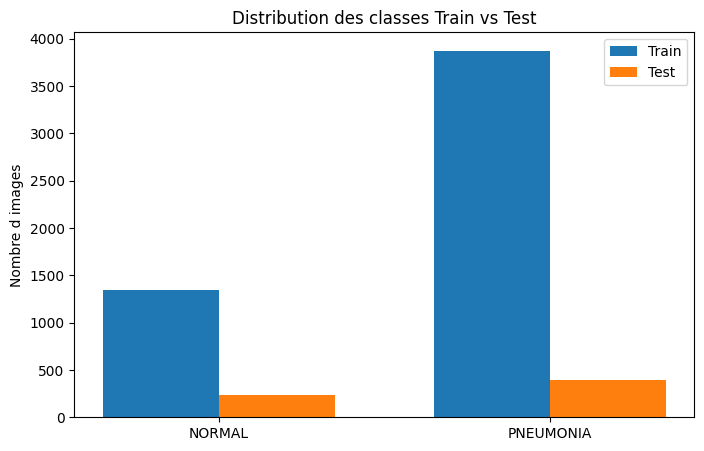

  NORMAL: 1341 (25.7%)
  PNEUMONIA: 3875 (74.3%)


In [5]:
# ==========================
# 5. ANALYSE EXPLORATOIRE
# ==========================

# ── Distribution des classes ───────────────────────────────────────
summary = (images_df.groupby(['subset','label']).size()
           .reset_index(name='count').sort_values(['subset','label']))
display(summary)

train_counts = count_per_class(train_root)
test_counts  = count_per_class(test_root)
labels       = sorted(train_counts.keys())

x = np.arange(len(labels))
w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w/2, [train_counts[l] for l in labels], width=w, label='Train')
plt.bar(x + w/2, [test_counts.get(l, 0) for l in labels], width=w, label='Test')
plt.xticks(x, labels)
plt.title('Distribution des classes Train vs Test')
plt.ylabel('Nombre d images')
plt.legend()
plt.show()

total = sum(train_counts.values())
for lbl, cnt in train_counts.items():
    print(f'  {lbl}: {cnt} ({cnt/total:.1%})')


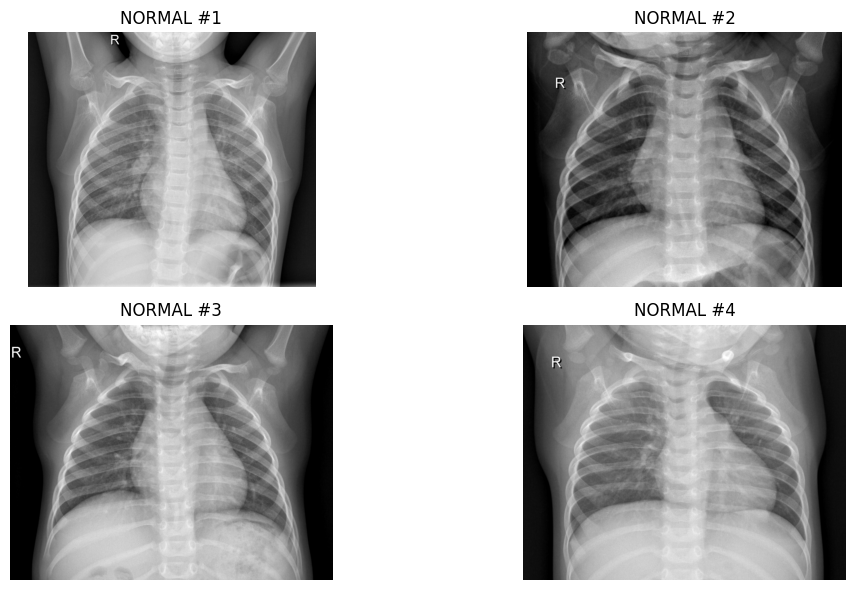

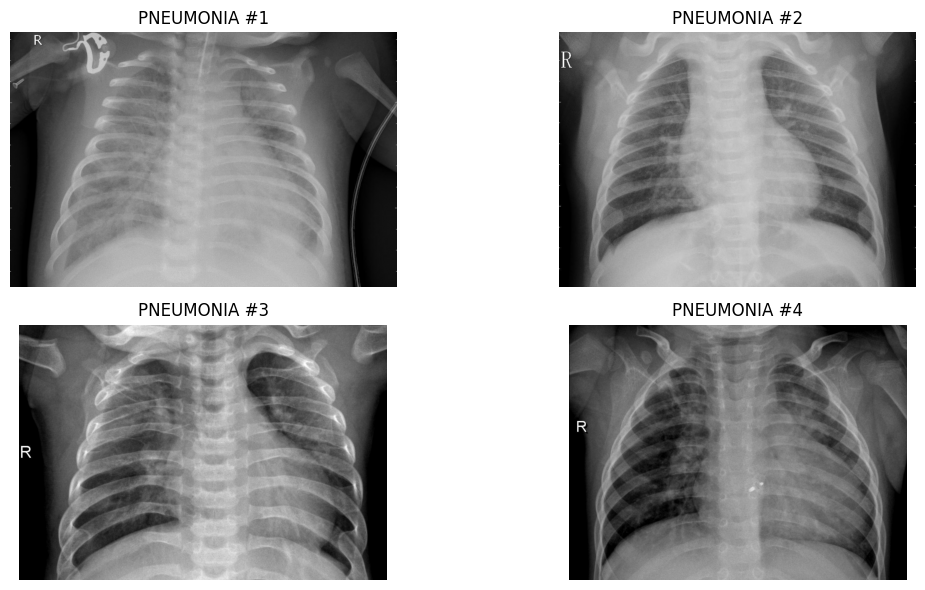

In [6]:
# ==========================
# 6. EXEMPLES D'IMAGES
# ==========================

normal_files    = list_images(normal_root)
pneumonia_files = list_images(pneumonia_root)

show_grid(normal_files,    'NORMAL',    n=4)
show_grid(pneumonia_files, 'PNEUMONIA', n=4)


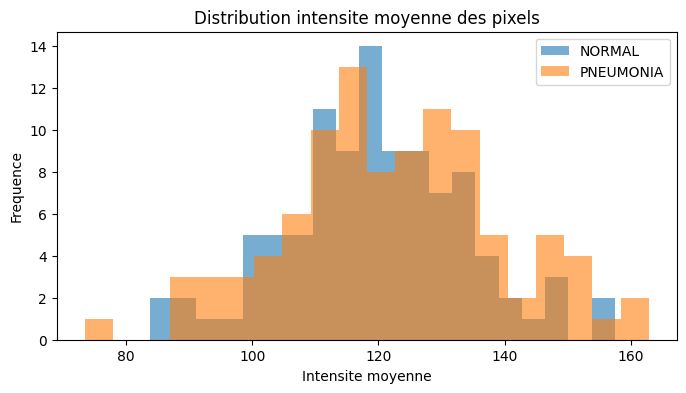

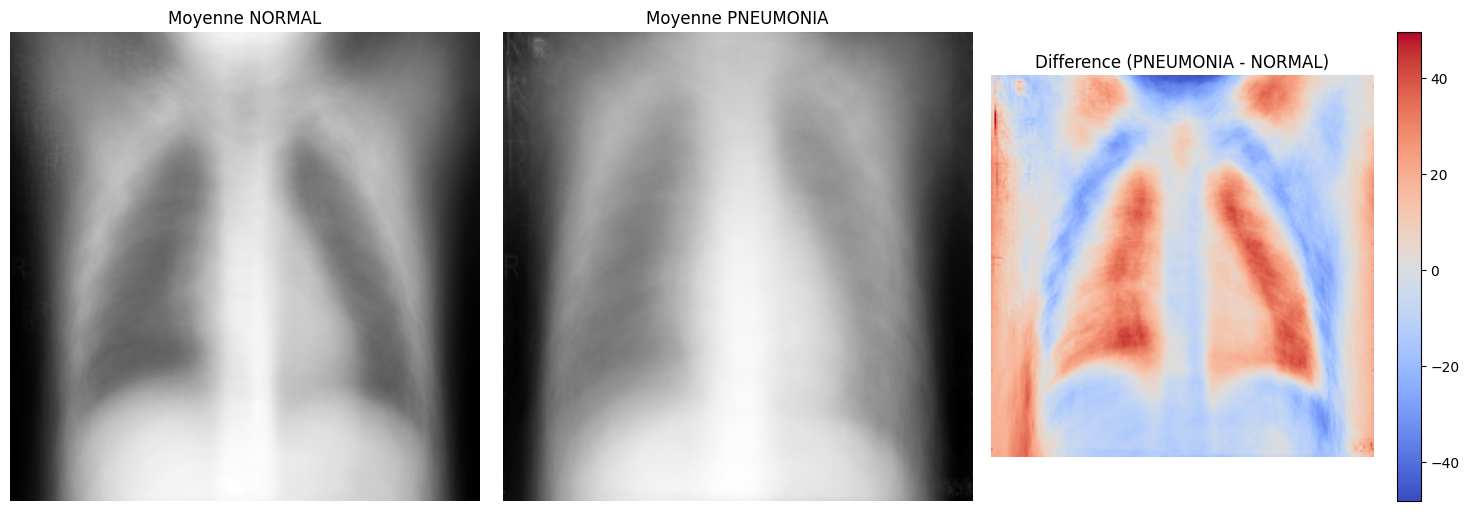

In [7]:
# ==========================
# 7. ANALYSE DES PIXELS & CONTRASTE
# ==========================

# Distributions d'intensité
n_means = [float(np.mean(read_gray(f))) for f in normal_files[:100]]
p_means = [float(np.mean(read_gray(f))) for f in pneumonia_files[:100]]

plt.figure(figsize=(8, 4))
plt.hist(n_means, bins=20, alpha=0.6, label='NORMAL')
plt.hist(p_means, bins=20, alpha=0.6, label='PNEUMONIA')
plt.title('Distribution intensite moyenne des pixels')
plt.xlabel('Intensite moyenne')
plt.ylabel('Frequence')
plt.legend()
plt.show()

# Images moyennes & carte de différence
SIZE_MEAN = (224, 224)
n_stack = np.array([read_gray(f, SIZE_MEAN) for f in normal_files[:100]])
p_stack = np.array([read_gray(f, SIZE_MEAN) for f in pneumonia_files[:100]])
mean_n  = n_stack.mean(axis=0)
mean_p  = p_stack.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mean_n, cmap='gray'); axes[0].set_title('Moyenne NORMAL');    axes[0].axis('off')
axes[1].imshow(mean_p, cmap='gray'); axes[1].set_title('Moyenne PNEUMONIA'); axes[1].axis('off')
heat = axes[2].imshow(mean_p - mean_n, cmap='coolwarm')
axes[2].set_title('Difference (PNEUMONIA - NORMAL)'); axes[2].axis('off')
plt.colorbar(heat, ax=axes[2])
plt.tight_layout()
plt.show()


In [8]:
# ==========================
# 8. CHARGEMENT NUMPY DES IMAGES
# ==========================

def load_images_numpy(folder, size, label):
    """Charge les images d'un dossier en tableau numpy normalisé [0,1]."""
    data, labels = [], []
    for fp in list_images(folder):
        try:
            img = read_gray(fp, size)
            data.append(img)
            labels.append(label)
        except Exception:
            pass
    arr = np.array(data, dtype='float32') / 255.0
    arr = arr[..., np.newaxis]   # (N, H, W, 1)
    return arr, np.array(labels, dtype='float32')

print('Chargement des images train...')
x_normal,    y_normal    = load_images_numpy(normal_root,    (IMG_SIZE, IMG_SIZE), label=1)
x_pneumonia, y_pneumonia = load_images_numpy(pneumonia_root, (IMG_SIZE, IMG_SIZE), label=0)

print(f'  NORMAL    : {x_normal.shape}')
print(f'  PNEUMONIA : {x_pneumonia.shape}')

# Assemblage complet
x_all = np.concatenate([x_normal, x_pneumonia], axis=0)
y_all = np.concatenate([y_normal, y_pneumonia], axis=0)

# Chargement du test
print('Chargement des images test...')
x_test_n, y_test_n = load_images_numpy(test_root / 'NORMAL',    (IMG_SIZE, IMG_SIZE), label=1)
x_test_p, y_test_p = load_images_numpy(test_root / 'PNEUMONIA', (IMG_SIZE, IMG_SIZE), label=0)
x_test = np.concatenate([x_test_n, x_test_p], axis=0)
y_test = np.concatenate([y_test_n, y_test_p], axis=0)
print(f'  Test : {x_test.shape}')


Chargement des images train...
  NORMAL    : (1341, 150, 150, 1)
  PNEUMONIA : (3875, 150, 150, 1)
Chargement des images test...
  Test : (624, 150, 150, 1)


In [9]:
# ==========================
# 9. SPLIT RÉEL TRAIN / VAL
# ==========================

x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_all
)

print(f'Train : {x_train.shape}  — PNEUMONIA: {int((y_train==0).sum())}  NORMAL: {int((y_train==1).sum())}')
print(f'Val   : {x_val.shape}    — PNEUMONIA: {int((y_val==0).sum())}    NORMAL: {int((y_val==1).sum())}')
print(f'Test  : {x_test.shape}   — PNEUMONIA: {int((y_test==0).sum())}   NORMAL: {int((y_test==1).sum())}')


Train : (4172, 150, 150, 1)  — PNEUMONIA: 3099  NORMAL: 1073
Val   : (1044, 150, 150, 1)    — PNEUMONIA: 776    NORMAL: 268
Test  : (624, 150, 150, 1)   — PNEUMONIA: 390   NORMAL: 234


## GAN Keras — Rééquilibrage de la classe minoritaire

Le GAN est implémenté en **Keras/TensorFlow** .


Le GAN apprend à générer des images de la classe NORMAL (minoritaire).
Les images synthétiques sont ensuite ajoutées au train pour rééquilibrer.

In [10]:
# ==========================
# 10. PARAMÈTRES DU GAN
# ==========================

LATENT_DIM = 100

# Images de la classe minoritaire redimensionnées à GAN_IMG_SIZE
# pour accélérer l'entraînement du GAN
minority_idx = np.where(y_train == 1)[0]   # NORMAL = classe minoritaire
majority_idx = np.where(y_train == 0)[0]   # PNEUMONIA = classe majoritaire

n_minority = len(minority_idx)
n_majority = len(majority_idx)
n_to_generate = int(n_minority * GAN_FILL_RATIO)   # images à générer

print(f'Classe minoritaire (NORMAL)    : {n_minority} images')
print(f'Classe majoritaire (PNEUMONIA) : {n_majority} images')
print(f'Images à générer               : {n_to_generate}')

# Préparer les images minoritaires en 64x64 pour le GAN
x_minority_full = x_train[minority_idx]  # (N, 150, 150, 1)
x_minority_gan  = np.array([
    cv2.resize(img[:, :, 0], (GAN_IMG_SIZE, GAN_IMG_SIZE))
    for img in x_minority_full
], dtype='float32')[..., np.newaxis]  # (N, 64, 64, 1)

# Normaliser vers [-1, 1] pour le GAN
x_minority_gan = x_minority_gan * 2.0 - 1.0
print(f'Dataset GAN : {x_minority_gan.shape}  range [{x_minority_gan.min():.2f}, {x_minority_gan.max():.2f}]')


Classe minoritaire (NORMAL)    : 1073 images
Classe majoritaire (PNEUMONIA) : 3099 images
Images à générer               : 751
Dataset GAN : (1073, 64, 64, 1)  range [-1.00, 1.00]


In [11]:
# ==========================
# 11. ARCHITECTURE DU VAE (Keras)
# ==========================

"""
def build_generator(latent_dim, img_size=64):
    """Générateur : bruit latent -> image 64x64x1."""
    model = keras.Sequential([
        # Projection et reshape
        layers.Dense(4 * 4 * 512, use_bias=False, input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((4, 4, 512)),

        # 4x4 -> 8x8
        layers.Conv2DTranspose(256, 4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # 8x8 -> 16x16
        layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # 16x16 -> 32x32
        layers.Conv2DTranspose(64, 4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # 32x32 -> 64x64
        layers.Conv2DTranspose(1, 4, strides=2, padding='same',
                               activation='tanh'),  # sortie dans [-1,1]
    ], name='generator')
    return model


def build_discriminator(img_size=64):
    """Discriminateur : image 64x64x1 -> probabilité réel/faux."""
    model = keras.Sequential([
        layers.Conv2D(64, 4, strides=2, padding='same', input_shape=(img_size, img_size, 1)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1),
    ], name='discriminator')
    return model


generator     = build_generator(LATENT_DIM, GAN_IMG_SIZE)
discriminator = build_discriminator(GAN_IMG_SIZE)

generator.summary()
discriminator.summary()
"""

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_encoder(latent_dim, img_size=64):
    encoder_inputs = keras.Input(shape=(img_size, img_size, 1))
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')


def build_decoder(latent_dim, img_size=64):
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 128, activation='relu')(latent_inputs)
    x = layers.Reshape((8, 8, 128))(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=1, padding='same', activation='relu')(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, strides=1, padding='same', activation='tanh')(x)
    return keras.Model(latent_inputs, decoder_outputs, name='decoder')


class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.001, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=(1, 2, 3)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result(),
        }


encoder = build_encoder(LATENT_DIM, GAN_IMG_SIZE)
decoder = build_decoder(LATENT_DIM, GAN_IMG_SIZE)
vae_model = VAE(encoder, decoder, beta=0.001)

encoder.summary()
decoder.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,607,297 (13.76 MB)

 Trainable params: 3,590,017 (13.69 MB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,217 (2.57 MB)

 Trainable params: 673,217 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================
# 12. ENTRAÎNEMENT DU VAE
# ==========================

"""
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)


@tf.function
def train_step(real_images):
    batch = tf.shape(real_images)[0]
    noise = tf.random.normal([batch, LATENT_DIM])

    with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        d_loss = (cross_entropy(tf.ones_like(real_output),  real_output) +
                  cross_entropy(tf.zeros_like(fake_output), fake_output))
        g_loss =  cross_entropy(tf.ones_like(fake_output),  fake_output)

    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)

    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return d_loss, g_loss


# Dataset
gan_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_minority_gan)
    .shuffle(len(x_minority_gan), seed=SEED)
    .batch(BATCH_GAN, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Début entraînement GAN — {EPOCHS_GAN} epochs')
g_losses, d_losses = [], []

for epoch in range(1, EPOCHS_GAN + 1):
    epoch_d, epoch_g = [], []
    for real_batch in gan_dataset:
        d_l, g_l = train_step(real_batch)
        epoch_d.append(float(d_l))
        epoch_g.append(float(g_l))

    d_losses.append(np.mean(epoch_d))
    g_losses.append(np.mean(epoch_g))

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS_GAN} — D_loss: {d_losses[-1]:.4f}  G_loss: {g_losses[-1]:.4f}')

print('GAN entraîné.')
"""

vae_optimizer = keras.optimizers.Adam(learning_rate=2e-4)
vae_model.compile(optimizer=vae_optimizer)

vae_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_minority_gan)
    .shuffle(len(x_minority_gan), seed=SEED)
    .batch(BATCH_GAN, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Debut entrainement VAE - {EPOCHS_GAN} epochs')
vae_history = vae_model.fit(vae_dataset, epochs=EPOCHS_GAN, verbose=1)
vae_total_losses = vae_history.history['loss']
vae_reconstruction_losses = vae_history.history['reconstruction_loss']
vae_kl_losses = vae_history.history['kl_loss']
print('VAE entraine.')


Début entraînement GAN — 350 epochs
  Epoch   1/350 — D_loss: 0.9937  G_loss: 0.8593
  Epoch  10/350 — D_loss: 1.3125  G_loss: 0.6980
  Epoch  20/350 — D_loss: 1.3714  G_loss: 0.7351
  Epoch  30/350 — D_loss: 1.3477  G_loss: 0.7215
  Epoch  40/350 — D_loss: 1.3045  G_loss: 0.6981
  Epoch  50/350 — D_loss: 1.3215  G_loss: 0.7350
  Epoch  60/350 — D_loss: 1.2958  G_loss: 0.7407
  Epoch  70/350 — D_loss: 1.3162  G_loss: 0.7488
  Epoch  80/350 — D_loss: 1.2884  G_loss: 0.7691
  Epoch  90/350 — D_loss: 1.2898  G_loss: 0.7506
  Epoch 100/350 — D_loss: 1.3031  G_loss: 0.7627
  Epoch 110/350 — D_loss: 1.2968  G_loss: 0.7699
  Epoch 120/350 — D_loss: 1.2859  G_loss: 0.7665
  Epoch 130/350 — D_loss: 1.2876  G_loss: 0.7859
  Epoch 140/350 — D_loss: 1.2314  G_loss: 0.8201
  Epoch 150/350 — D_loss: 1.2471  G_loss: 0.8041
  Epoch 160/350 — D_loss: 1.2664  G_loss: 0.8264
  Epoch 170/350 — D_loss: 1.2066  G_loss: 0.8232
  Epoch 180/350 — D_loss: 1.2360  G_loss: 0.8347
  Epoch 190/350 — D_loss: 1.2442 

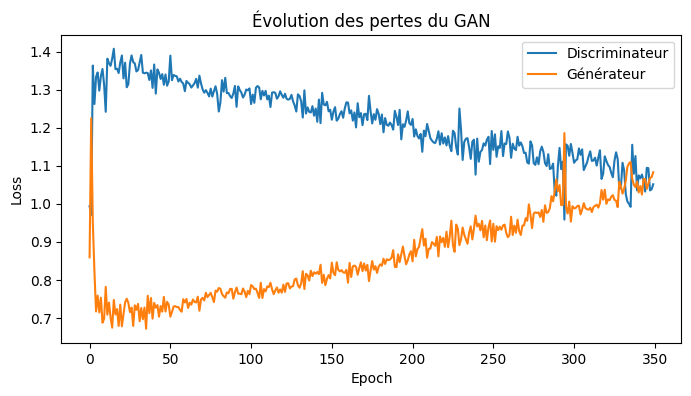

In [13]:
# ==========================
# 13. COURBES DE PERTE DU VAE
# ==========================

plt.figure(figsize=(8, 4))
plt.plot(vae_total_losses, label='Loss totale')
plt.plot(vae_reconstruction_losses, label='Reconstruction')
plt.plot(vae_kl_losses, label='KL')
plt.title('Évolution des pertes du VAE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


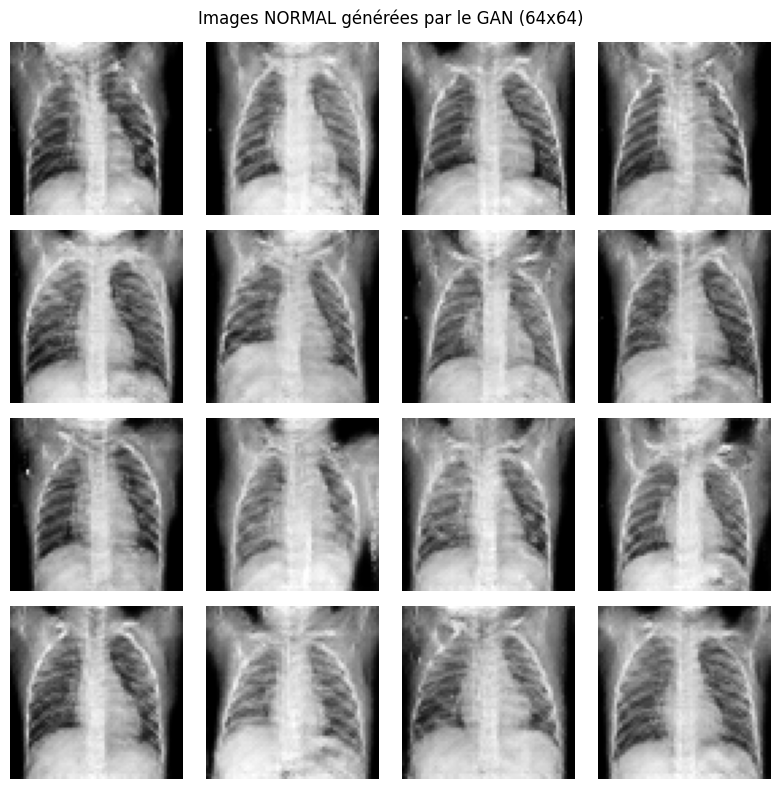

In [14]:
# ==========================
# 14. APERÇU DES IMAGES GÉNÉRÉES PAR LE VAE
# ==========================

latent_preview = tf.random.normal([16, LATENT_DIM])
fake_preview  = decoder(latent_preview, training=False).numpy()
fake_preview  = (fake_preview + 1.0) / 2.0   # dénormaliser vers [0,1]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_preview[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('Images NORMAL générées par le VAE (64x64)')
plt.tight_layout()
plt.show()


In [15]:
# ==========================
# 15. GÉNÉRATION ET INJECTION DANS LE TRAIN
# ==========================

print(f'Generation de {n_to_generate} images synthetiques NORMAL via le VAE...')

batch_size_gen = 256
generated_batches = []
n_remaining = n_to_generate

while n_remaining > 0:
    nb = min(batch_size_gen, n_remaining)
    latent_samples = tf.random.normal([nb, LATENT_DIM])
    imgs  = decoder(latent_samples, training=False).numpy()
    imgs  = (imgs + 1.0) / 2.0   # -> [0, 1]
    # Redimensionner de 64x64 -> IMG_SIZE x IMG_SIZE
    imgs_resized = np.array([
        cv2.resize(img[:, :, 0], (IMG_SIZE, IMG_SIZE))
        for img in imgs
    ], dtype='float32')[..., np.newaxis]
    generated_batches.append(imgs_resized)
    n_remaining -= nb

x_synthetic = np.concatenate(generated_batches, axis=0)
y_synthetic = np.ones(len(x_synthetic), dtype='float32')  # label NORMAL = 1

# Libérer la mémoire du VAE avant le CNN
del vae_dataset, x_minority_gan, generated_batches
del encoder, decoder, vae_model
gc.collect()
tf.keras.backend.clear_session()  # libère les variables Keras

# Réimporter TF
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
tf.random.set_seed(SEED)
for gpu in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except: pass

# Construire le train équilibré
x_train_bal = np.concatenate([x_train, x_synthetic], axis=0)
y_train_bal = np.concatenate([y_train, y_synthetic], axis=0)

# Mélanger
idx = np.random.permutation(len(x_train_bal))
x_train_bal = x_train_bal[idx]
y_train_bal = y_train_bal[idx]

print(f'Train rééquilibré : {x_train_bal.shape}')
print(f'  NORMAL    : {int((y_train_bal==1).sum())}')
print(f'  PNEUMONIA : {int((y_train_bal==0).sum())}')


Génération de 751 images synthétiques NORMAL...
Train rééquilibré : (4923, 150, 150, 1)
  NORMAL    : 1824
  PNEUMONIA : 3099


## CNN — Classification finale



In [16]:
# ==========================
# 16. DATA AUGMENTATION
# ==========================

datagen_train = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)
datagen_train.fit(x_train_bal)

print('Data augmentation configurée.')


Data augmentation configurée.


In [17]:
# ==========================
# 17. ARCHITECTURE CNN
# ==========================


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, BatchNormalization,
    Dropout, Flatten, Dense
)

cnn_model = Sequential([
    # Bloc 1
    Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
           input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    BatchNormalization(),
    MaxPool2D((2,2), strides=2, padding='same'),

    # Bloc 2
    Conv2D(64, (3,3), strides=1, padding='same', activation='relu'),
    Dropout(0.1),
    BatchNormalization(),
    MaxPool2D((2,2), strides=2, padding='same'),

    # Bloc 3
    Conv2D(64, (3,3), strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D((2,2), strides=2, padding='same'),

    # Bloc 4
    Conv2D(128, (3,3), strides=1, padding='same', activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    MaxPool2D((2,2), strides=2, padding='same'),

    # Bloc 5
    Conv2D(256, (3,3), strides=1, padding='same', activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    MaxPool2D((2,2), strides=2, padding='same'),

    # Classifieur
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [18]:
cnn_callbacks = [
    callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', patience=2, verbose=1,
        factor=0.3, min_lr=1e-6
    )
]

history = cnn_model.fit(
    datagen_train.flow(x_train_bal, y_train_bal, batch_size=BATCH_CNN),
    epochs=EPOCHS_CNN,
    validation_data=(x_val, y_val),
    callbacks=cnn_callbacks
)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 34s 144ms/step - accuracy: 0.8028 - auc: 0.8800 - loss: 0.6356 - precision: 0.7360 - recall: 0.7292 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 17.6963 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8907 - auc: 0.9579 - loss: 0.2681 - precision: 0.8468 - recall: 0.8607 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 10.7666 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9145 - auc: 0.9676 - loss: 0.2265 - precision: 0.8773 - recall: 0.8872
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9173 - auc: 0.9687 - loss: 0.2286 - precision: 0.8878 - recall: 0.8893 - val_accuracy: 0.7433 - val_auc: 0.5187 - val_loss: 4.9069 - val_precision: 0.0000e+00 - val_recall: 0

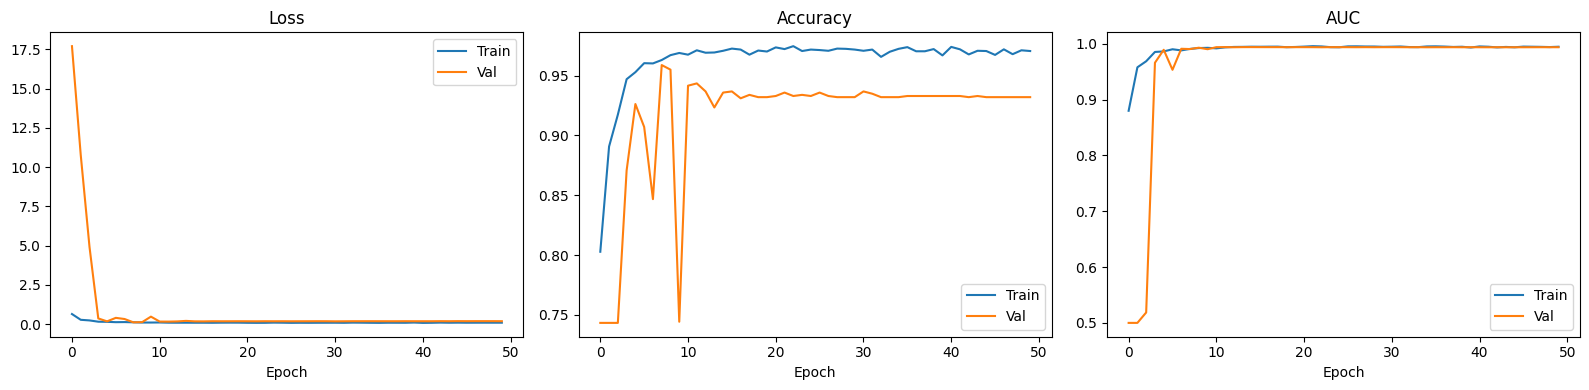

In [19]:
# ==========================
# 19. COURBES D'APPRENTISSAGE
# ==========================

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_df['loss'],     label='Train')
axes[0].plot(history_df['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['accuracy'],     label='Train')
axes[1].plot(history_df['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_df['auc'],     label='Train')
axes[2].plot(history_df['val_auc'], label='Val')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()


In [44]:
# ==========================
# 21. ÉVALUATION FINALE SUR LE TEST
# ==========================

y_prob = cnn_model.predict(x_test, verbose=1).ravel()
y_pred = (y_prob >= 0.45).astype('int32')

print(f'Loss    : {cnn_model.evaluate(x_test, y_test, verbose=0)[0]:.4f}')
print(f'Accuracy: {np.mean(y_pred == y_test)*100:.2f} %')
print(f'AUC     : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Seuil   : {0.45}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Pneumonia (0)', 'Normal (1)'],
    zero_division=0
))


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Loss    : 0.2579
Accuracy: 92.63 %
AUC     : 0.9653
Seuil   : 0.45

               precision    recall  f1-score   support

Pneumonia (0)       0.94      0.94      0.94       390
   Normal (1)       0.90      0.90      0.90       234

     accuracy                           0.93       624
    macro avg       0.92      0.92      0.92       624
 weighted avg       0.93      0.93      0.93       624



<Figure size 600x500 with 0 Axes>

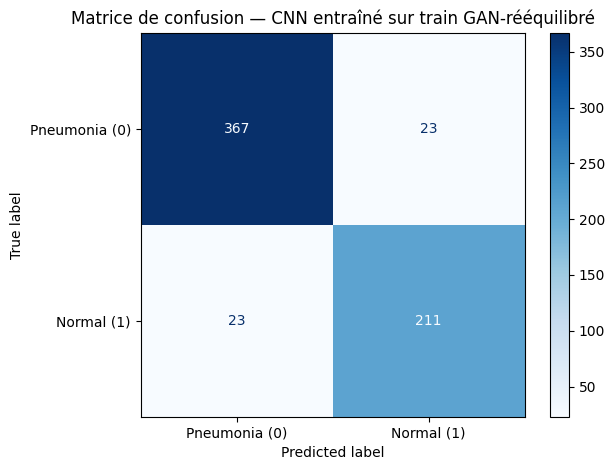

In [32]:
# ==========================
# 22. MATRICE DE CONFUSION
# ==========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(
    cm, display_labels=['Pneumonia (0)', 'Normal (1)']
).plot(values_format='d', cmap='Blues')
plt.title('Matrice de confusion — CNN entraîné sur train GAN-rééquilibré')
plt.tight_layout()
plt.show()


In [45]:
# ==========================
# 23. SAUVEGARDE DU MODÈLE FINAL
# ==========================

cnn_model.save("pneumonia_cnn_model.h5")
cnn_model.save("pneumonia_cnn_model.keras")

print("modèle cnn sauvegardé avec succès")


modèle cnn sauvegardé avec succès


In [58]:
from pathlib import Path
import os

print("cwd =", Path.cwd())

export_path = Path.cwd() / "pneumonia_cnn_model.keras"
cnn_model.save(export_path)

print("saved =", export_path.resolve())
print("exists =", export_path.exists())
print("files =", [p.name for p in Path.cwd().glob("*.keras")])


cwd = /content
saved = /content/pneumonia_cnn_model.keras
exists = True
files = ['c:\\Users\\Administrator\\Desktop\\pneumonia-ai-workspace\\backend\\pneumonia_cnn_model.keras', 'pneumonia_cnn_model.keras']


In [59]:
from google.colab import files
files.download("/content/pneumonia_cnn_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# ==========================
# 24. CHARGEMENT DU MODÈLE SAUVEGARDÉ
# ==========================

from tensorflow import keras

loaded_cnn_model = keras.models.load_model("pneumonia_cnn_model.keras")

print("modèle chargé avec succès")
loaded_cnn_model.summary()

modèle chargé avec succès


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,491,716 (9.51 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

 Optimizer params: 1,245,315 (4.75 MB)

In [47]:
# ==========================
# 25. VÉRIFICATION APRÈS CHARGEMENT
# ==========================

from sklearn.metrics import classification_report, roc_auc_score

y_prob_loaded = loaded_cnn_model.predict(x_test, verbose=1).ravel()
y_pred_loaded = (y_prob_loaded >= 0.45).astype("int32")

print(f'Loss    : {loaded_cnn_model.evaluate(x_test, y_test, verbose=0)[0]:.4f}')
print(f'Accuracy: {np.mean(y_pred_loaded == y_test)*100:.2f} %')
print(f'AUC     : {roc_auc_score(y_test, y_prob_loaded):.4f}')
print(f'Seuil   : {0.45}')
print()

print(classification_report(
    y_test,
    y_pred_loaded,
    target_names=['Pneumonia (0)', 'Normal (1)'],
    zero_division=0
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step
Loss    : 0.2579
Accuracy: 92.63 %
AUC     : 0.9653
Seuil   : 0.45

               precision    recall  f1-score   support

Pneumonia (0)       0.94      0.94      0.94       390
   Normal (1)       0.90      0.90      0.90       234

     accuracy                           0.93       624
    macro avg       0.92      0.92      0.92       624
 weighted avg       0.93      0.93      0.93       624



In [48]:
# ==========================
# 26. PRÉDICTION SUR UNE NOUVELLE IMAGE
# ==========================

def preprocess_new_xray(image_path, img_size=IMG_SIZE):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")

    img = cv2.resize(img, (img_size, img_size))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)   # (H, W, 1)
    img = np.expand_dims(img, axis=0)    # (1, H, W, 1)
    return img

def predict_new_xray(image_path, model, threshold=0.45):
    img = preprocess_new_xray(image_path)
    prob = model.predict(img, verbose=0).ravel()[0]
    pred = int(prob >= threshold)

    label_map = {
        0: "Pneumonia",
        1: "Normal"
    }

    print(f"probabilité classe 1 (Normal) : {prob:.4f}")
    print(f"seuil utilisé                  : {threshold}")
    print(f"classe prédite                 : {pred} -> {label_map[pred]}")

    return prob, pred

In [49]:
# ==========================
# 27. EXEMPLE DE PRÉDICTION
# ==========================

new_image_path = test_root / "NORMAL" / list_images(test_root / "NORMAL")[0].name

prob, pred = predict_new_xray(new_image_path, loaded_cnn_model, threshold=0.45)

probabilité classe 1 (Normal) : 0.9741
seuil utilisé                  : 0.45
classe prédite                 : 1 -> Normal


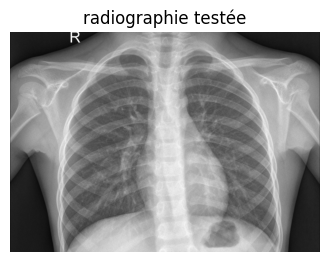

In [50]:
# ==========================
# 28. VISUALISATION DE L'IMAGE TESTÉE
# ==========================

img_show = cv2.imread(str(new_image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4,4))
plt.imshow(img_show, cmap='gray')
plt.title("radiographie testée")
plt.axis("off")
plt.show()